In [1]:
import os
import redis

REDIS_URL = os.getenv('REDIS_URL', 'redis://localhost:6379')

r = redis.Redis.from_url(REDIS_URL)
try:
    r.ping()
    print("✅ Connected to Redis successfully!")
except redis.ConnectionError:
    print(f"❌ Failed to connect to Redis at {REDIS_URL}")

❌ Failed to connect to Redis at redis://localhost:6379


In [2]:
question = "Is the first quartile the lowest 25% of the data or the highest?"
answer = (
    "For any quantile (percentile, quartile, quintile, etc.), the first quantile is the lowest portion of the data, "
    "and the last quantile is the highest. For example, the first quartile (Q1) represents the value for which 25% "
    "of the data falls below it, while the second quartile (Q2) is the median, representing the value for which 50% "
    "of the data falls below it. The first percentile (P1) represents the value for which 1% of the data falls below it, "
    "and the 99th percentile (P99) represents the value for which 99% of the data falls below it. Although sometimes "
    "people to the 'first quartile' or 'first percentile' as the top portion, this is not how it's used in statistics."
    "However, it is correct to say 'top quartile' or 'top percentile' when referring to the highest portion of the data."
)

In [3]:
# Make a list of questions that should lead to the same answer
positive_queries = [
    "What does the first quartile (Q1) represent in statistics?",
    "Is the first quantile the lowest or highest portion of the data?",
    "What percentile corresponds to the median?",
    "What does the 99th percentile mean?",
    "What does it mean when 25% of the data falls below a value?",
    "Is it correct to call the first quartile the top quartile?",
    "How are percentiles defined in terms of data below a value?",
    "What is the difference between 'first percentile' and 'top percentile'?",
    "Which part of the data does the first quantile refer to?",
    "Why is it incorrect to refer to the first quartile as the highest portion of the data?"
]

# These questions may seem related to quantiles but would not be answered by the reference chunk
hard_negative_queries = [
    "How do you compute quartiles for a dataset with an even number of observations?",
    "What interpolation methods are used to calculate percentiles in NumPy or pandas?",
    "How do box plots use quartiles to identify outliers?",
    "What is the difference between population and sample quantiles?",
    "How do quantiles relate to the cumulative distribution function (CDF)?",
    "When should you prefer quantiles over mean and standard deviation?",
    "How are quantiles used in quantile regression?",
    "What is the impact of skewed data on percentile interpretation?",
    "How do you efficiently compute approximate quantiles on very large datasets?",
    "What are deciles, and how are they used in income inequality analysis?"
]

# These questions are unrelated to the reference chunk
soft_negative_queries = [
    "What's the difference between the mean and the median?",
    "How do you calculate the mode of a dataset?",
    "What is standard deviation and how is it computed?",
    "Can you explain variance in statistics?",
    "What is a normal distribution?",
    "How do you interpret a box plot?",
    "What are outliers and how are they detected?",
    "What is the difference between correlation and causation?",
    "What is the power of a test?",
    "How do you perform a t-test?"
]
# Test semantic similarity thresholding

In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    model_kwargs={"device_map": "auto"},
    tokenizer_kwargs={"padding_side": "left"},
)
print(model.device)

# Embed the question

/Users/benjaminbasseri/Dropbox/Studies/Programming/aiml/semantic-cache/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mps:0


In [5]:
chunk_vector = model.encode(answer)
print(f"Chunk vector shape: {chunk_vector.shape}")

positive_vectors = model.encode(positive_queries)
print(f"Positive vectors shape: {positive_vectors.shape}")

hard_negative_vectors = model.encode(hard_negative_queries)
print(f"Hard negative vectors shape: {hard_negative_vectors.shape}")

soft_negative_vectors = model.encode(soft_negative_queries)
print(f"Soft negative vectors shape: {soft_negative_vectors.shape}")

Chunk vector shape: (1024,)
Positive vectors shape: (10, 1024)
Hard negative vectors shape: (10, 1024)
Soft negative vectors shape: (10, 1024)


In [6]:
import torch.nn.functional as F
import torch

def cos_distance(a, b):
    return 1 - F.cosine_similarity(a, b)

positive_distances = cos_distance(torch.tensor(chunk_vector), torch.tensor(positive_vectors))
hard_negative_distances = cos_distance(torch.tensor(chunk_vector), torch.tensor(hard_negative_vectors))
soft_negative_distances = cos_distance(torch.tensor(chunk_vector), torch.tensor(soft_negative_vectors))

In [17]:
import numpy as np
print(np.max(positive_distances.numpy()))
print(np.min(hard_negative_distances.numpy()))

0.36381745
0.36436474


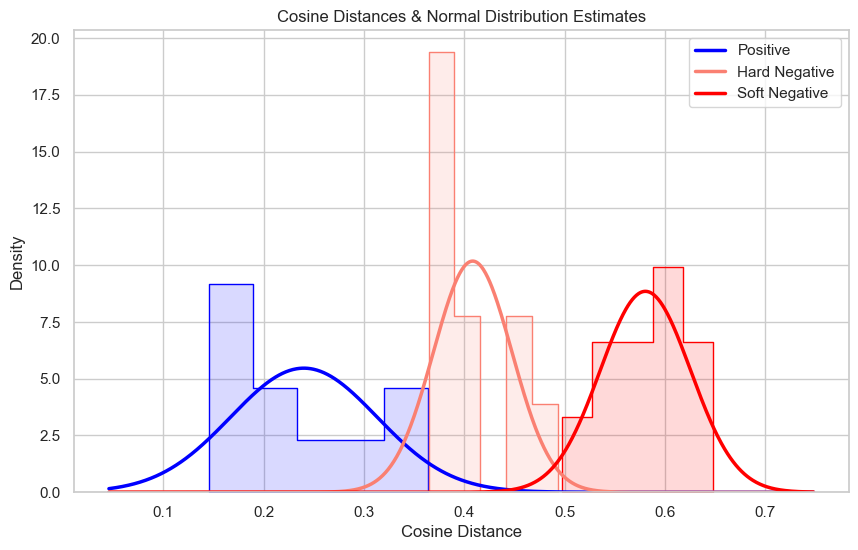

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
pos_data = positive_distances.cpu().numpy()
hard_neg_data = hard_negative_distances.cpu().numpy()
soft_neg_data = soft_negative_distances.cpu().numpy()

# Define X-axis range for the lines
all_data = np.concatenate([pos_data, hard_neg_data, soft_neg_data])
x_axis = np.linspace(all_data.min() - 0.1, all_data.max() + 0.1, 1000)

# Helper to calculate Gaussian PDF using only NumPy


def get_normal_pdf(x, data):
    mu = np.mean(data)
    sigma = np.std(data)
    # The Gaussian Probability Density Function formula
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


def plot_with_numpy(data, color, label):
    # 1. Plot histogram
    sns.histplot(data, color=color, stat="density",
                 element="step", alpha=0.15, kde=False)

    # 2. Calculate and plot the curve manually
    y_axis = get_normal_pdf(x_axis, data)
    plt.plot(x_axis, y_axis, color=color,
             label=f'{label}', linewidth=2.5)


plot_with_numpy(pos_data, "blue", "Positive")
plot_with_numpy(hard_neg_data, "salmon", "Hard Negative")
plot_with_numpy(soft_neg_data, "red", "Soft Negative")

plt.title("Cosine Distances & Normal Distribution Estimates")
plt.xlabel("Cosine Distance")
plt.ylabel("Density")
plt.legend()
plt.show()